In [1]:
import sys
import time
import serial
import glob
from jii_multispeq.measurement import measure
import jii_multispeq.device as device
from matplotlib import pyplot as plt
import numpy as np
from helpers import (
    findDevice, set_voltage, set_current, get_par_MP, get_par_AMB,
    r_squared, plot_data_and_fit, set_par_gain, set_ambit_led_gain,
    set_ambit_led, ambit_reboot, AmbitInfo
)


In [5]:
# Initialize ports for MiniPAR
PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)

Received message: 
Received message: MiniPAR,V1.1
Found device at: /dev/ttyACM2, answer: MiniPAR,V1.1



In [2]:
# Initialize ports for DC supply
PORT_DC_SOURCE = findDevice(question="*IDN?\n", answer="KIPRIM", flush=True, timeout=2)

Received message: KIPRIM,DC310S,25011669,FV:V5.2.0
Found device at: /dev/ttyUSB0, answer: KIPRIM,DC310S,25011669,FV:V5.2.0



In [14]:
# Initialize ports for Ambit
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)
PORT_AMBIT = findDevice(question="hello\n", answer="NEW", flush=True, timeout=4)




Received message: 
Received message: MiniPAR,V1.1
Received message: BAD COMMAND
Received message: MiniPAR,V1.1
No matching device found.
Received message: 
Received message: MiniPAR,V1.1
Received message: NEW Name Here Ready
Found device at: /dev/ttyACM1, answer: NEW Name Here Ready



In [15]:
# Helper functions have been moved to helpers.py
print(get_par_MP(PORT_MINIPAR))
print(get_par_AMB(PORT_AMBIT, raw = True))

2.21
10.58


In [16]:
# callibration of the light sensor in the Ambit

currents = [0.2, 0.4, 0.8, 1.0, 1.6, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_current(port=PORT_DC_SOURCE, current=I)
    time.sleep(1.0)
    ref_val = get_par_MP(PORT_MINIPAR)
    sens_val = get_par_AMB(PORT_AMBIT, raw=True)
    reference_data.append(ref_val)
    sensor_data.append(sens_val)

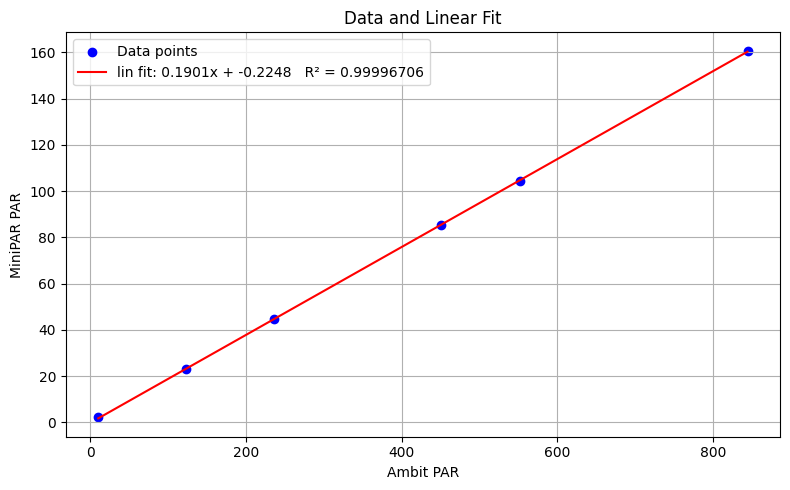

In [17]:
# Analysis functions
# (r_squared and plot_data_and_fit are now imported from helpers.py)

y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)
plot_data_and_fit(x, y, coeffs, r2, xlabel="Ambit PAR", ylabel="MiniPAR PAR")


In [18]:
# Upload PAR calibration coefficients to the Ambit
# This section demonstrates how to use set_par_gain
from helpers import set_par_gain, ambit_reboot, AmbitInfo

# Example:
slope = coeffs[0]
#offset = coeffs[1]
info = ambit_reboot(PORT_AMBIT)
old_slope =info.light_slope
print(f"Uploading PAR gain: {slope:.4f}")
set_par_gain(PORT_AMBIT, slope)
info = ambit_reboot(PORT_AMBIT)

print(f"Old PAR gain: {old_slope:.4f}, New PAR gain: {info.light_slope:.4f}") 



Uploading PAR gain: 0.1901
Old PAR gain: 0.1161, New PAR gain: 0.1901


In [19]:

# Callibration of the light emmission of the Ambit LED
#ambit_reboot(PORT_AMBIT)
currents = [  10, 20, 60, 90, 150, 0]
reference_data = []
sensor_data = []
for I in currents:
    set_ambit_led(PORT_AMBIT, I)
    time.sleep(0.2)
    sens_val = get_par_MP(PORT_MINIPAR)
    reference_data.append(I)
    sensor_data.append(sens_val)
   


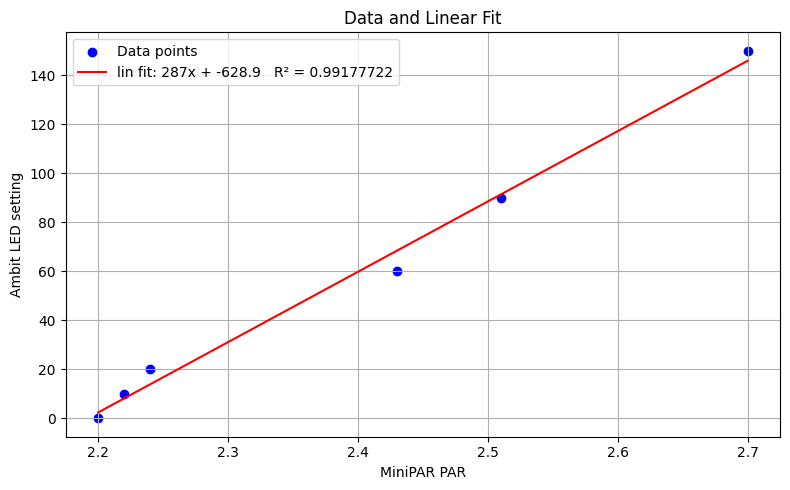

In [20]:
# inspection plot for LED callibration
y = reference_data
x = sensor_data
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
r2 = r_squared(y, y_pred)

plot_data_and_fit(x,y, coeffs, r2, ylabel="Ambit LED setting", xlabel="MiniPAR PAR")

In [12]:
# Upload LED gain calibration to the Ambit
light_gain = coeffs[0]
info = ambit_reboot(PORT_AMBIT)
old_slope = info.act_led_coeff
set_ambit_led_gain(PORT_AMBIT, light_gain)
info = ambit_reboot(PORT_AMBIT)
print(f"Old LED gain: {old_slope:.4f}, New LED gain: {info.act_led_coeff:.4f}")

Old LED gain: 602.4096, New LED gain: 1421.7687
